In [1]:
import sys
import os

# 1. Clone the Repository
# We clone into the temporary /kaggle/working directory
if not os.path.exists("/kaggle/working/UniversalSAE"):
    print("Cloning repository...")
    !git clone https://github.com/yorkucvil/UniversalSAE.git
else:
    print("Repository already exists.")

# 2. Add to Python Path
# This tells Python to look inside the UniversalSAE folder for imports
repo_path = "/kaggle/working/UniversalSAE"
if repo_path not in sys.path:
    sys.path.append(repo_path)
    print(f"Added {repo_path} to sys.path")

# 3. Verify Imports
try:
    import universal_sae
    import overcomplete
    print("✅ Success: Libraries imported successfully.")
except ImportError as e:
    print(f"❌ Error: {e}")
    print("Contents of repo:", os.listdir(repo_path))

# 4. Install Dependencies
# (Optional: Only if the repo has extra requirements not in Kaggle)
# !pip install -r /kaggle/working/UniversalSAE/requirements.txt

Repository already exists.
Added /kaggle/working/UniversalSAE to sys.path


/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

✅ Success: Libraries imported successfully.


In [2]:
from kaggle_secrets import UserSecretsClient
import wandb

try:
    # 1. Retrieve the key from Kaggle Secrets
    user_secrets = UserSecretsClient()
    api_key = user_secrets.get_secret("WANDB_API_KEY")
    
    # 2. Set it as an environment variable
    os.environ["WANDB_API_KEY"] = api_key
    
    # 3. Login to verify
    # wandb.login()
    
    # 4. Ensure the mode is set to online (overriding previous 'disabled' instructions)
    os.environ["WANDB_MODE"] = "online"
    
    print("✅ Successfully logged in to Weights & Biases!")
    
except Exception as e:
    print(f"❌ Could not log in: {e}")
    print("Make sure you added the secret via Add-ons > Secrets with label 'WANDB_API_KEY'")

✅ Successfully logged in to Weights & Biases!


In [3]:
# ==========================================
# GLOBAL IMPORTS & CONFIG
# ==========================================
import os
import glob
import gc
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim
from tqdm.notebook import tqdm
from collections import defaultdict
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import CIFAR10 
import torchvision.transforms as T

# Library Imports
from overcomplete.models import ViT, ResNet
from overcomplete.sae import TopKSAE
from overcomplete.sae.losses import top_k_auxiliary_loss
from universal_sae.train import train_cross_prediction_saes

# Global Config
CACHE_DIR = "./cached_activations"
SPLIT = "train"
BATCH_SIZE = 32
NUM_IMAGES = 1000 
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

INPUT_DIMS = {"ResNet": 2048, "ViT": 768}
NB_CONCEPTS = 16384 
TOP_K = 32 

# Helper to clean GPU memory between stages
def cleanup_gpu():
    gc.collect()
    torch.cuda.empty_cache()
    print("GPU Cache Cleared.")

In [19]:
import random

In [4]:
# ==========================================
# STAGE 1: DATA CACHING
# ==========================================
print(">>> STAGE 1: Caching Activations")

# 1. Load Source Models
models = {
    "ResNet": ResNet(device=DEVICE),
    "ViT": ViT(device=DEVICE)
}

transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 2. Prepare Fake Data
dataset = CIFAR10(root='./data', train=True, download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

# 3. Cache Loop
save_dir = os.path.join(CACHE_DIR, SPLIT)
os.makedirs(save_dir, exist_ok=True)

with torch.no_grad():
    for i, (images, labels) in enumerate(tqdm(dataloader)):
        images = images.to(DEVICE)
        batch_acts = {}
        
        for name, model in models.items():
            # 1. Get Raw Features
            acts = model.forward_features(images)
            
            # 2. Apply Specific Pooling per Architecture
            if name == "ResNet":
                # Input: (B, 2048, 7, 7) -> Avg Pool Spatial Dims (2,3)
                # Result: (B, 2048)
                acts = acts.mean(dim=(2, 3))
            elif name == "ViT":
                # Input: (B, 196, 768) -> Avg Pool Tokens (1)
                # Result: (B, 768)
                acts = acts.mean(dim=1)
                
            # 3. Add Fake 'Token' Dimension for Universal Library Compatibility
            # Shape becomes (B, 1, C)
            acts = acts.unsqueeze(1)
            
            batch_acts[name] = acts.cpu().numpy()
            
        np.savez(
            os.path.join(save_dir, f"batch_{i}_combined.npz"),
            **batch_acts,
            labels=labels.numpy()
        )

# CRITICAL: Delete models to free VRAM for training
del models
cleanup_gpu()

>>> STAGE 1: Caching Activations


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

  0%|          | 0/1563 [00:00<?, ?it/s]

GPU Cache Cleared.



>>> STAGE 2: Training USAEs (Normalized)
-----HERE-----
--DEFAULT ENCODER INITIALIZED--
-----HERE-----
--DEFAULT ENCODER INITIALIZED--


wandb: Currently logged in as: 27100179 (27100179-lahore-university-of-management-sciences) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


epoch progress: 100%|██████████| 1563/1563 [00:58<00:00, 26.62it/s]


Epoch[1/10], Loss: 0.0016, R2: 3.0074, Sparsity: 0.9980, Time: 58.7242 seconds


epoch progress: 100%|██████████| 1563/1563 [00:57<00:00, 26.95it/s]


...

epoch progress: 100%|██████████| 1563/1563 [00:57<00:00, 26.98it/s]


Epoch[9/10], Loss: 0.0009, R2: 403.8565, Sparsity: 0.9980, Time: 57.9295 seconds


epoch progress: 100%|██████████| 1563/1563 [00:58<00:00, 26.91it/s]


Epoch[10/10], Loss: 0.0008, R2: 412.5070, Sparsity: 0.9980, Time: 58.0856 seconds


ResNet_lr,▇▃▅▇▂▁▇▃▂▂▁▅▃▇▇▇▆▃▂▂▅▅▆▃▇▁█▂▁▂▇▆▇▅▁▃▂▆▁▇
ViT_lr,█▃▅▃▅▇▂▁██▂▁▁█▃▁▃▇▅▇█▁▂▁▂▇▅▁▂▃▇▇▆▁▇▇▇▅▂▁
avg_loss,████▅▅▅▄▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
cross_R2,▁▃▅▆▆▇▇███
step_loss,██▆▇▇▅▅▄▄▄▃▃▃▃▃▃▃▃▂▂▃▂▂▂▂▁▂▂▂▁▂▂▁▁▂▁▁▁▁▂
time_epoch,██▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▂▂▁▁▁▁▁▁▁▁▁
z_sparsity,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
ResNet_lr,0.00025
ViT_lr,0.00025
avg_loss,0.00084
cross_R2,0.50589


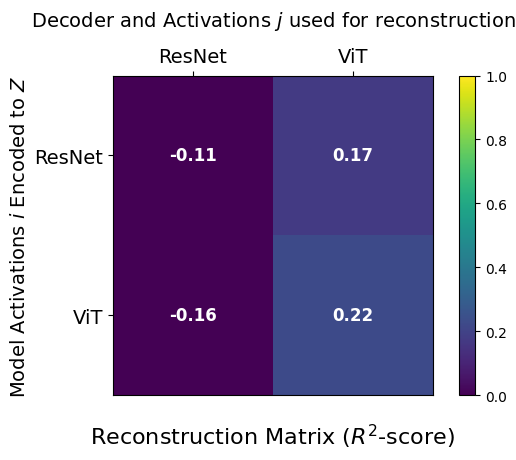

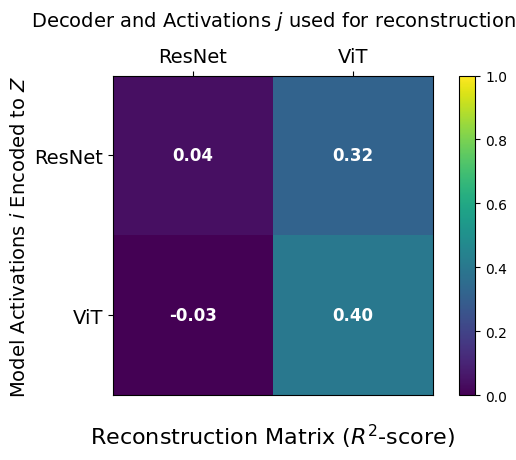

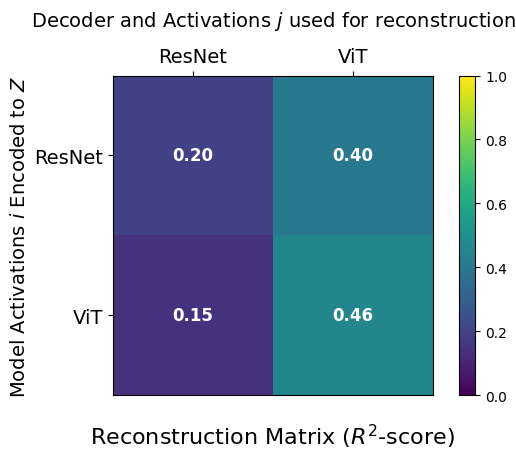

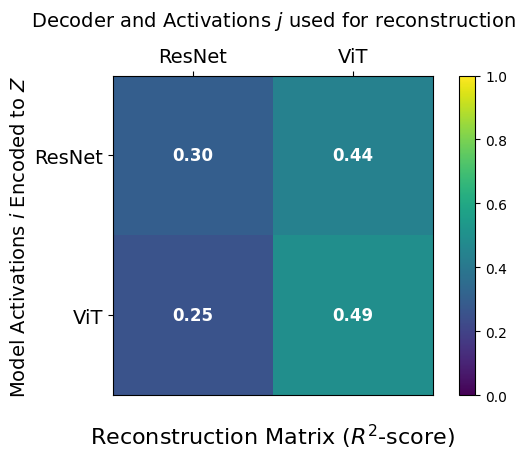

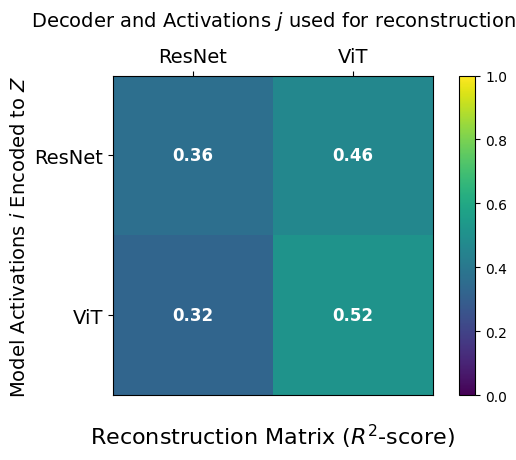

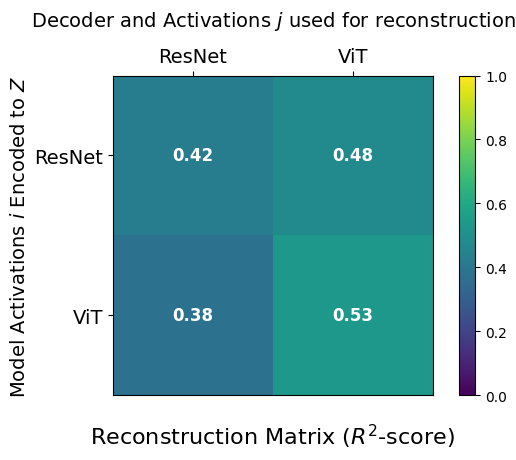

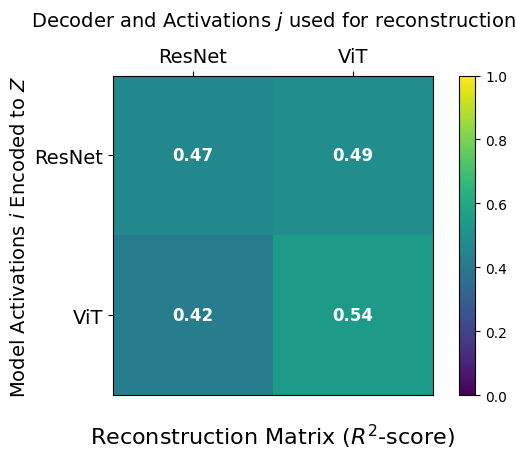

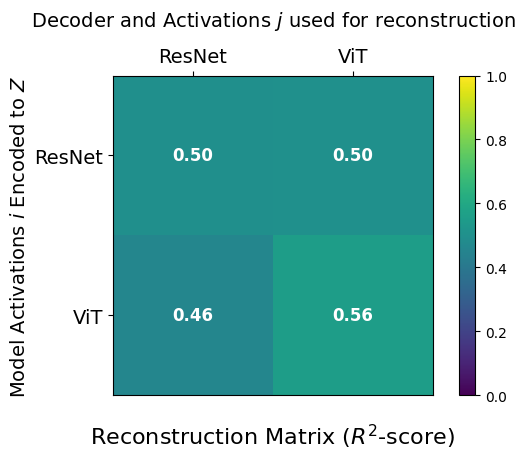

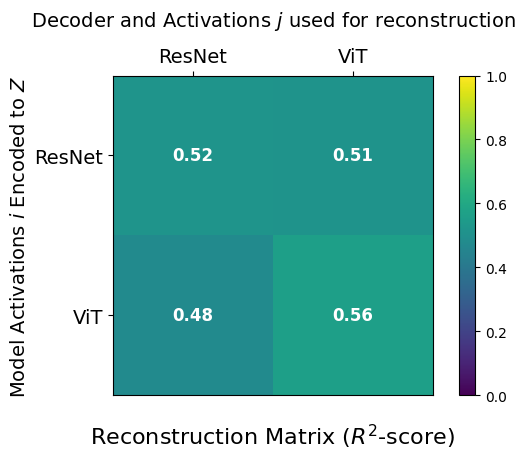

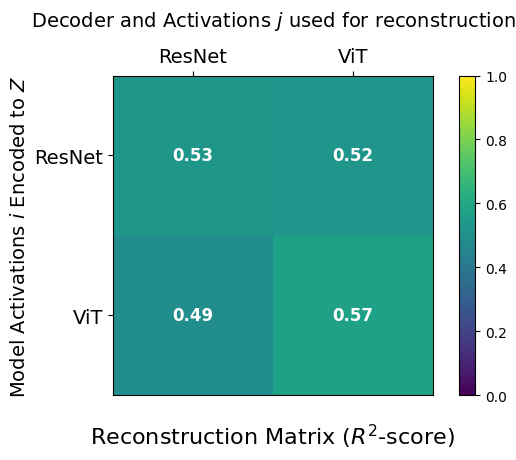

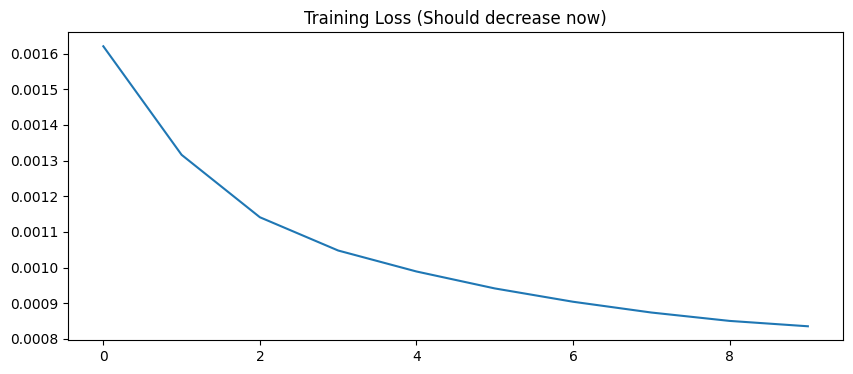

GPU Cache Cleared.


In [4]:
# ==========================================
# STAGE 2: UNIVERSAL SAE TRAINING (FIXED NORMALIZATION)
# ==========================================
from torch.optim.lr_scheduler import CosineAnnealingLR

print("\n>>> STAGE 2: Training USAEs (Normalized)")

# 1. Define Normalized Dataset
class CachedActDataset(Dataset):
    def __init__(self, cache_dir, normalize=True):
        self.files = sorted(glob.glob(os.path.join(cache_dir, "*.npz")))
        self.normalize = normalize
        
    def __len__(self): return len(self.files)
    
    def __getitem__(self, idx):
        data = np.load(self.files[idx])
        acts = {}
        for k, v in data.items():
            if k == 'labels': continue
            
            tensor = torch.from_numpy(v)
            
            # L2 Normalization
            # This puts ResNet and ViT on the same geometric scale (Unit Sphere)
            if self.normalize:
                # tensor shape is (32, 1, Dim)
                # We normalize along the last dimension (Dim)
                norm = tensor.norm(dim=-1, keepdim=True)
                # Avoid division by zero
                tensor = tensor / (norm + 1e-6)
                
            acts[k] = tensor
            
        return acts, torch.from_numpy(data['labels'])

# 2. Init SAEs
saes = {}
optimizers = {}

# Higher LR because we are using a Scheduler now
LEARNING_RATE = 5e-4 

for model_name, d_in in INPUT_DIMS.items():
    saes[model_name] = TopKSAE(
        input_shape=d_in,
        n_components=NB_CONCEPTS,
        top_k=TOP_K,
        device=DEVICE
    )
    optimizers[model_name] = optim.Adam(saes[model_name].parameters(), lr=LEARNING_RATE)

# 3. Train
dataset = CachedActDataset(os.path.join(CACHE_DIR, "train"), normalize=True)

train_loader = DataLoader(
    dataset, 
    batch_size=1, 
    shuffle=True,
    collate_fn=lambda x: x[0]
)

# Structured config for the library
structured_model_zoo = {k: {"input_shape": v} for k, v in INPUT_DIMS.items()}

# Create Schedulers (Optional but helps convergence)
schedulers = {
    k: CosineAnnealingLR(optimizers[k], T_max=10) for k in saes
}

logs = train_cross_prediction_saes(
    saes=saes,
    dataloader=train_loader,
    criterion=top_k_auxiliary_loss,
    sae_optimizers=optimizers,
    sae_schedulers=schedulers,
    model_zoo=structured_model_zoo,
    nb_epochs=10,
    device=DEVICE,
    monitoring=1
)

# 4. Save & Plot
os.makedirs("checkpoints", exist_ok=True)
for name, model in saes.items():
    torch.save(model.state_dict(), f"checkpoints/{name}_usae.pth")

plt.figure(figsize=(10,4))
plt.plot(logs['avg_loss'])
plt.title("Training Loss (Should decrease now)")
plt.show()

cleanup_gpu()


>>> STAGE 3: Analyzing Universality


Analyzing activations:   0%|          | 0/1563 [00:00<?, ?it/s]

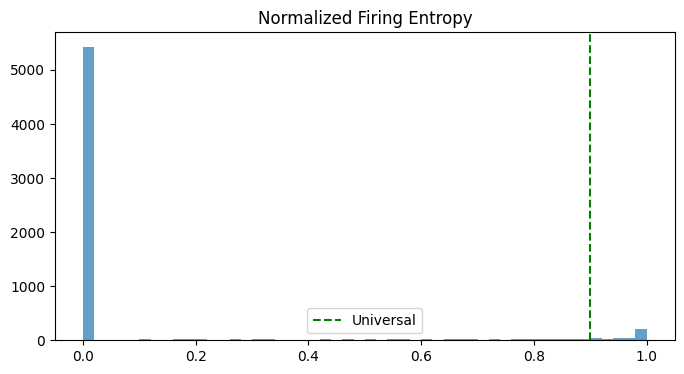

In [5]:
# ==========================================
# STAGE 3: METRICS (ENTROPY & R2)
# ==========================================
print("\n>>> STAGE 3: Analyzing Universality")

# Ensure SAEs are in Eval mode
for sae in saes.values(): sae.eval()

concept_fires = {name: torch.zeros(NB_CONCEPTS, device=DEVICE) for name in saes}
analysis_loader = DataLoader(dataset, batch_size=1, collate_fn=lambda x: x[0])

# 1. Compute Firing Frequency
with torch.no_grad():
    for batch_acts, _ in tqdm(analysis_loader, desc="Analyzing activations"):
        for name, acts in batch_acts.items():
            acts = acts.to(DEVICE)
            if acts.ndim == 3:
                acts = acts.squeeze(1)
            _, z = saes[name].encode(acts)
            fires = (z > 0).float().sum(dim=0)
            concept_fires[name] += fires

# 2. Compute Entropy
M = len(saes)
total_fires = sum(concept_fires.values())
valid_mask = total_fires > 0

sum_p_log_p = torch.zeros(NB_CONCEPTS, device=DEVICE)
epsilon = 1e-9

for name in saes:
    p_i = torch.zeros_like(total_fires)
    p_i[valid_mask] = concept_fires[name][valid_mask] / total_fires[valid_mask]
    sum_p_log_p += p_i * torch.log(p_i + epsilon)

entropy = -1 / np.log(M) * sum_p_log_p
entropy = entropy.cpu().numpy()

plt.figure(figsize=(8, 4))
plt.hist(entropy[valid_mask.cpu().numpy()], bins=50, alpha=0.7)
plt.title("Normalized Firing Entropy")
plt.axvline(0.9, color='g', linestyle='--', label='Universal')
plt.legend()
plt.show()

In [24]:
# CIFAR-10 Class Names
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
# Note: CIFAR uses 'automobile' instead of 'car' and 'airplane' instead of 'plane'

def find_features_for_class(target_class, num_top=3):
    try:
        target_label = classes.index(target_class)
    except ValueError:
        print(f"Error: '{target_class}' not found. Available classes: {classes}")
        return None

    print(f"Searching for features specific to '{target_class}' (Label {target_label})...")
    
    # Accumulator for feature importance
    feature_sums = torch.zeros(NB_CONCEPTS, device=DEVICE)
    
    # Use the cached loader
    # collate_fn=lambda x: x[0] extracts the (32, ...) batch from the list
    loader = DataLoader(dataset, batch_size=1, collate_fn=lambda x: x[0])
    
    total_images_found = 0
    
    with torch.no_grad():
        for i, batch in enumerate(loader):
            # batch[0] = Dict of activations {'ResNet': (32, 1, 2048), ...}
            # batch[1] = Labels (32,)
            
            labels = batch[1].to(DEVICE)
            
            # Create a mask for the target class
            # e.g., [False, True, False, ...]
            mask = (labels == target_label)
            
            # If no cars in this batch, skip
            if mask.sum() == 0: continue
                
            total_images_found += mask.sum().item()
            
            # Get ResNet activations for ONLY the cars
            acts = batch[0]['ResNet'].to(DEVICE)
            
            # 1. Handle Dimensions: (32, 1, 2048) -> (32, 2048)
            if acts.ndim == 3:
                acts = acts.squeeze(1)
                
            # 2. Filter: Keep only 'car' activations
            # Shape becomes (Num_Cars, 2048)
            relevant_acts = acts[mask]
            
            # 3. Normalize (Critical!)
            relevant_acts = relevant_acts / (relevant_acts.norm(dim=-1, keepdim=True) + 1e-6)
            
            # 4. Encode
            _, z = saes['ResNet'].encode(relevant_acts)
            
            # 5. Sum up activations
            feature_sums += z.sum(dim=0)
            
            if i > 200: break # Scan 200 batches (approx 6400 images)
            
    if total_images_found == 0:
        print("Warning: No images of that class found in the scanned batches.")
        return 0

    # Find the features with the highest total activation
    top_indices = torch.topk(feature_sums, num_top).indices.cpu().numpy()
    
    print(f"Found {total_images_found} examples.")
    print(f"Top features for '{target_class}': {top_indices}")
    return top_indices[0]

# 2. Auto-select a good feature (High Consensus)
# We need a feature index that actually does something for BOTH models
def get_best_feature_index(dataset):
    print("Searching for a shared feature...")
    loader = DataLoader(dataset, batch_size=1, collate_fn=lambda x: x[0])
    
    # Accumulate firings for first 50 batches to save time
    fires = {k: torch.zeros(NB_CONCEPTS, device=DEVICE) for k in saes}
    
    with torch.no_grad():
        for i, batch in enumerate(loader):
            if i > 100: break

            # Unpack tuple (Activations, Label)
            if isinstance(batch, (tuple, list)):
                batch_acts = batch[0]
            else:
                batch_acts = batch
                
            for name, acts in batch_acts.items():
                acts = acts.to(DEVICE)
                # Fix dimensions if needed
                if acts.ndim == 3: acts = acts.squeeze(1)
                
                _, z = saes[name].encode(acts)
                fires[name] += (z > 0).float().sum(dim=0)
    
    # Find intersection (Minimum firing count across both)
    consensus = torch.min(fires['ResNet'], fires['ViT'])
    
    # Pick the one with highest overlap
    best_idx = torch.argmax(consensus).item()
    count = consensus[best_idx].item()
    
    print(f"Selected Feature #{best_idx} (Fired {int(count)} times in both models)")
    return best_idx

# 3. Robust Optimization Loop
def optimize_feature_robust(target_k, model_name, steps=150):
    # Start with gray noise (0.5)
    img = torch.randn(1, 3, 224, 224, device=DEVICE) * 0.01 + 0.5
    img.requires_grad = True
    
    optimizer = torch.optim.Adam([img], lr=0.05)
    blur = T.GaussianBlur(5, sigma=0.8)
    
    for i in range(steps):
        optimizer.zero_grad()
        
        # A. Forward Pass (Vision Model)
        acts = vis_models[model_name].forward_features(img)
        
        # B. Handle Dimensions
        if model_name == "ResNet": acts = acts.mean(dim=(2, 3))
        elif model_name == "ViT":  acts = acts.mean(dim=1)
            
        # C. CRITICAL FIX: Normalize Activations
        # The SAE expects Unit Norm inputs now!
        acts = acts / (acts.norm(dim=-1, keepdim=True) + 1e-6)
        
        # D. SAE Encode
        _, z = saes[model_name].encode(acts)
        
        # E. Maximize Target
        activation = z[:, target_k].mean()
        loss = -activation
        
        # Regularization (Keep image roughly valid)
        loss += 0.05 * torch.norm(img) 
        
        loss.backward()
        optimizer.step()
        
        # Smoothing trick to remove static
        if i % 4 == 0:
            with torch.no_grad(): img.copy_(blur(img))
                
    return img.detach().cpu().squeeze().permute(1, 2, 0)

# def optimize_feature_robust(target_k, model_name, steps=250):
#     # Start with gray
#     img = torch.randn(1, 3, 224, 224, device=DEVICE) * 0.01 + 0.5
#     img.requires_grad = True
    
#     optimizer = torch.optim.Adam([img], lr=0.05)
    
#     # Augmentations to force SHAPE robustness
#     jitter = T.ColorJitter(brightness=0.1, contrast=0.1)
#     # We will manually apply shifts/rotations
    
#     for i in range(steps):
#         optimizer.zero_grad()
        
#         # 1. Robustness: Randomly shift/scale/rotate the image slightly
#         # This prevents the model from relying on pixel-perfect texture noise
#         ox, oy = random.randint(-4, 4), random.randint(-4, 4)
#         rolled_img = torch.roll(img, shifts=(ox, oy), dims=(2, 3))
        
#         # 2. Forward
#         acts = vis_models[model_name].forward_features(rolled_img)
        
#         if model_name == "ResNet": acts = acts.mean(dim=(2, 3))
#         elif model_name == "ViT":  acts = acts.mean(dim=1)
            
#         acts = acts / (acts.norm(dim=-1, keepdim=True) + 1e-6)
#         _, z = saes[model_name].encode(acts)
        
#         # 3. Objective
#         loss = -z[:, target_k].mean()
        
#         # 4. L2 Regularization (keep pixels normal)
#         loss += 0.02 * torch.norm(img)
        
#         loss.backward()
#         optimizer.step()
        
#         # 5. Gaussian Blur (Crucial for eliminating high-freq texture)
#         if i % 2 == 0:
#             with torch.no_grad():
#                 img.copy_(T.GaussianBlur(3, sigma=0.5)(img))
#                 # Clamp to valid image range
#                 img.clamp_(0, 1)

#     return img.detach().cpu().squeeze().permute(1, 2, 0)

In [9]:
# ==========================================
# HELPER: FIND SHARED SEMANTIC FEATURES (FIXED)
# ==========================================
import pandas as pd

def find_shared_semantic_features(
    dataset, 
    saes, 
    classes, 
    device="cuda", 
    num_batches=100, 
    top_k_results=3
):
    """
    Scans the dataset to find features that are:
    1. Semantic: Highly selective for a specific class (High Purity).
    2. Shared: Active in BOTH models for that class.
    """
    print(f"🔎 Scanning {num_batches} batches for shared semantic features...")
    
    # --- FIX: Use global constant or decoder weights instead of encoder ---
    # Since NB_CONCEPTS is global, we can use it. 
    # Or generically: saes["ResNet"].n_components
    nb_concepts = NB_CONCEPTS 
    
    num_classes = len(classes)
    
    # Accumulators: [Model][Feature_Idx][Class_Idx]
    class_activations = {
        name: torch.zeros((nb_concepts, num_classes), device=device) 
        for name in saes.keys()
    }
    
    loader = DataLoader(dataset, batch_size=1, shuffle=True, collate_fn=lambda x: x[0])
    
    # 1. Accumulate Class-Specific Activations
    with torch.no_grad():
        for i, (batch_acts, batch_labels) in enumerate(loader):
            if i >= num_batches: break
            
            labels = batch_labels.to(device) # Shape (B,)
            
            for name, acts in batch_acts.items():
                acts = acts.to(device)
                if acts.ndim == 3: acts = acts.squeeze(1)
                
                # Normalize (Crucial for Universal SAEs)
                acts = acts / (acts.norm(dim=-1, keepdim=True) + 1e-6)
                
                _, latents = saes[name].encode(acts) # Shape (B, Features)
                
                # Add activations to the corresponding class bin
                for c in range(num_classes):
                    mask = (labels == c)
                    if mask.sum() > 0:
                        class_sum = latents[mask].sum(dim=0)
                        class_activations[name][:, c] += class_sum

    print("✅ Accumulation complete. Calculating scores...")

    results = []

    # 2. Calculate Purity and Consensus
    res_acts = class_activations["ResNet"].cpu() 
    vit_acts = class_activations["ViT"].cpu()   
    
    res_totals = res_acts.sum(dim=1, keepdim=True) + 1e-6
    vit_totals = vit_acts.sum(dim=1, keepdim=True) + 1e-6
    
    # Purity: Proportion of feature's energy devoted to class C
    res_purity = res_acts / res_totals
    vit_purity = vit_acts / vit_totals
    
    # Joint Purity: Geometric Mean (Both must be high)
    joint_purity = torch.sqrt(res_purity * vit_purity)
    
    # 3. Extract Top Features per Class
    for c_idx, class_name in enumerate(classes):
        class_scores = joint_purity[:, c_idx]
        
        # Filter dead features (must have some activity)
        total_fire = res_totals[:, 0] + vit_totals[:, 0]
        threshold = torch.quantile(total_fire, 0.5) # Ignore bottom 50% inactive features
        class_scores[total_fire < threshold] = 0
        
        top_values, top_indices = torch.topk(class_scores, top_k_results)
        
        for k in range(top_k_results):
            feat_idx = top_indices[k].item()
            score = top_values[k].item()
            
            if score > 0.4: 
                results.append({
                    "Class": class_name,
                    "Feature_ID": feat_idx,
                    "Joint_Purity": score,
                    "ResNet_Purity": res_purity[feat_idx, c_idx].item(),
                    "ViT_Purity": vit_purity[feat_idx, c_idx].item()
                })

    return pd.DataFrame(results)

In [10]:
df_semantic = find_shared_semantic_features(
    dataset, 
    saes, 
    cifar_classes, 
    device=DEVICE,
    num_batches=200 # Scans ~6400 images
)

# Display best candidates
print("\n🏆 Top Shared Semantic Candidates:")
display(df_semantic.sort_values(by="Joint_Purity", ascending=False).head(10))

# Automatically pick the best one for visualization
if not df_semantic.empty:
    best_row = df_semantic.loc[df_semantic['Joint_Purity'].idxmax()]
    best_feature_idx = int(best_row['Feature_ID'])
    best_class = best_row['Class']
    print(f"\nExample: Feature {best_feature_idx} is the best shared '{best_class}' detector.")
    
    # Run your robust visualization on this feature
    # optimize_feature_robust(best_feature_idx, "ResNet") ...
else:
    print("No strong semantic features found. Try increasing num_batches.")

🔎 Scanning 200 batches for shared semantic features...
✅ Accumulation complete. Calculating scores...

🏆 Top Shared Semantic Candidates:


,Class,Feature_ID,Joint_Purity,ResNet_Purity,ViT_Purity
15,dog,6664,0.999999,1.000000,0.999999
12,deer,1148,0.999999,0.999998,0.999999
9,cat,6826,0.999998,0.999999,0.999998
6,bird,3267,0.999998,1.000000,0.999996
16,dog,16189,0.999997,0.999998,0.999996
10,cat,7002,0.999995,0.999999,0.999991
18,frog,8727,0.999995,0.999996,0.999994
24,ship,10846,0.999994,0.999999,0.999990
7,bird,5636,0.999988,0.999981,0.999995
13,deer,9863,0.999988,0.999995,0.999981



Example: Feature 6664 is the best shared 'dog' detector.


In [15]:
def find_specific_semantic_features(dataset, saes, classes, device="cuda", num_batches=200):
    print(f"🔎 Scanning {num_batches} batches for CONTRASTIVE semantic features...")
    
    nb_concepts = NB_CONCEPTS
    num_classes = len(classes)
    
    # Accumulate raw activation sums per class
    # shape: [Features, Classes]
    accumulators = {
        k: torch.zeros((nb_concepts, num_classes), device=device) 
        for k in saes.keys()
    }
    
    loader = DataLoader(dataset, batch_size=1, shuffle=True, collate_fn=lambda x: x[0])
    
    with torch.no_grad():
        for i, (batch_acts, batch_labels) in enumerate(loader):
            if i >= num_batches: break
            labels = batch_labels.to(device)
            
            for name, acts in batch_acts.items():
                acts = acts.to(device)
                if acts.ndim == 3: acts = acts.squeeze(1)
                acts = acts / (acts.norm(dim=-1, keepdim=True) + 1e-6)
                
                _, latents = saes[name].encode(acts)
                
                for c in range(num_classes):
                    mask = (labels == c)
                    if mask.sum() > 0:
                        accumulators[name][:, c] += latents[mask].sum(dim=0)

    results = []
    
    # Analyze
    res_acts = accumulators["ResNet"].cpu()
    vit_acts = accumulators["ViT"].cpu()
    
    # Normalize across classes (Probability distribution per feature)
    # If Feature X fired 100 times: 90 times for Car, 10 times for Truck -> High Specificity
    res_dist = res_acts / (res_acts.sum(dim=1, keepdim=True) + 1e-6)
    vit_dist = vit_acts / (vit_acts.sum(dim=1, keepdim=True) + 1e-6)
    
    for feat_idx in range(nb_concepts):
        # 1. Get Top 2 Classes for this feature
        res_top_val, res_top_idx = torch.topk(res_dist[feat_idx], 2)
        vit_top_val, vit_top_idx = torch.topk(vit_dist[feat_idx], 2)
        
        # 2. Check: Do both models agree on the PRIMARY class?
        if res_top_idx[0] != vit_top_idx[0]:
            continue # Disagreement -> Skip
            
        target_class_idx = res_top_idx[0].item()
        target_class = classes[target_class_idx]
        
        # 3. Calculate "Specificity Gap"
        # (Score of Top Class) - (Score of 2nd Best Class)
        # If Gap is high, it doesn't fire for confusing classes (e.g. Dog vs Cat)
        res_gap = res_top_val[0] - res_top_val[1]
        vit_gap = vit_top_val[0] - vit_top_val[1]
        
        # 4. Joint Score
        joint_specificity = (res_gap + vit_gap) / 2
        joint_magnitude = (res_acts[feat_idx, target_class_idx] + vit_acts[feat_idx, target_class_idx])
        
        # Filters:
        # - Must be highly specific (>0.5 gap means 2nd class is very low)
        # - Must have fired reasonably often (magnitude > 10)
        if joint_specificity > 0.6 and joint_magnitude > 20:
            results.append({
                "Feature_ID": feat_idx,
                "Class": target_class,
                "Specificity": joint_specificity.item(),
                "Res_Gap": res_gap.item(),
                "ViT_Gap": vit_gap.item()
            })
            
    df = pd.DataFrame(results)
    return df.sort_values("Specificity", ascending=False)

In [16]:
# Run it
df_contrast = find_specific_semantic_features(dataset, saes, cifar_classes)
display(df_contrast.head(10))

🔎 Scanning 200 batches for CONTRASTIVE semantic features...


,Feature_ID,Class,Specificity,Res_Gap,ViT_Gap
13,4300,bird,0.982573,0.977040,0.988106
24,8584,frog,0.973999,0.971200,0.976797
41,14946,bird,0.970526,0.941051,1.000000
43,15923,bird,0.969238,0.965936,0.972540
6,1273,horse,0.968703,0.975394,0.962011
26,9471,frog,0.958086,0.979807,0.936364
39,14802,cat,0.952611,0.954293,0.950929
40,14914,car,0.952132,0.987304,0.916959
30,11053,car,0.949811,0.943788,0.955834
17,5689,horse,0.948211,0.923378,0.973044



>>> STAGE 4: Visualizing Consensus
Generating Visualizaiton for Feature #6664
Optimizing ResNet...
Optimizing ViT...


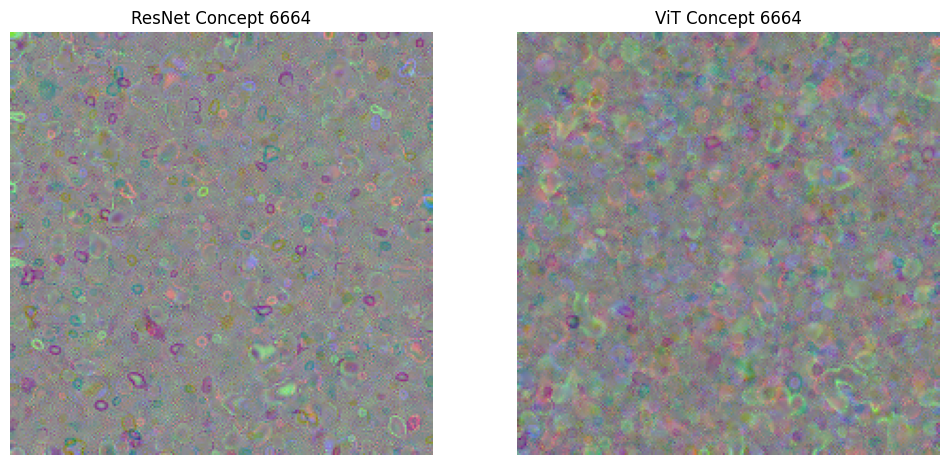

GPU Cache Cleared.


In [28]:
# ==========================================
# STAGE 4: VISUALIZATION (NORMALIZED & ROBUST)
# ==========================================
print("\n>>> STAGE 4: Visualizing Consensus")

# 1. Setup Visualization Models
vis_models = {
    "ResNet": ResNet(device=DEVICE),
    "ViT": ViT(device=DEVICE)
}

# Ensure SAEs in eval mode
for sae in saes.values(): sae.eval()

# EXAMPLE: Find 'automobile' (car) features
# Note: Use 'automobile', not 'car' for CIFAR-10 strict naming
specific_k = best_feature_idx

# 4. Execute
print(f"Generating Visualizaiton for Feature #{specific_k}")
print("Optimizing ResNet...")
img_resnet = optimize_feature_robust(specific_k, "ResNet")
print("Optimizing ViT...")
img_vit = optimize_feature_robust(specific_k, "ViT")

# 5. Plot
def normalize_view(img):
    img = img - img.min()
    img = img / (img.max() - img.min())
    return img

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(normalize_view(img_resnet))
ax[0].set_title(f"ResNet Concept {specific_k}")
ax[0].axis('off')

ax[1].imshow(normalize_view(img_vit))
ax[1].set_title(f"ViT Concept {specific_k}")
ax[1].axis('off')

plt.show()

# Final cleanup
del vis_models
cleanup_gpu()

Top 5 Activating Images for Feature 6664 (ResNet):


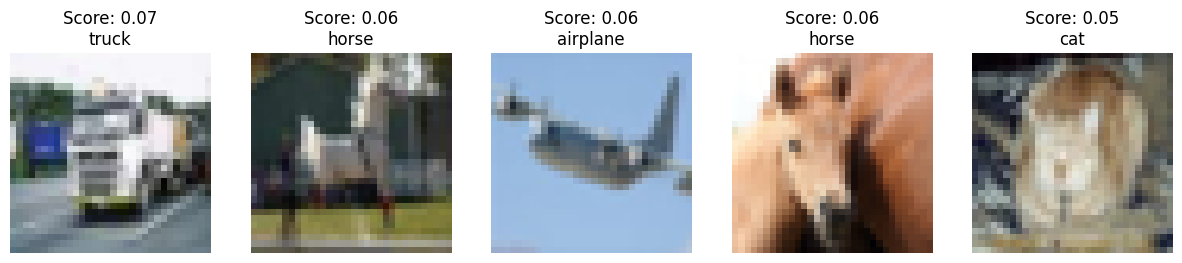

Top 5 Activating Images for Feature 6664 (ViT):


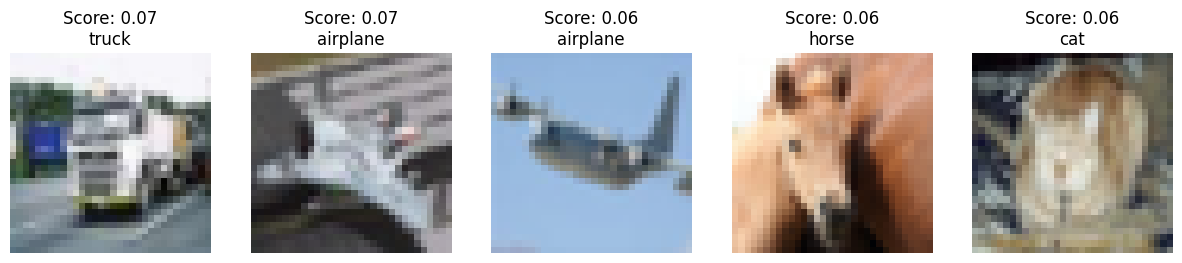

In [29]:
def show_max_activating_images(feature_k, model_name="ResNet"):
    # 1. Load Raw CIFAR Images (for display)
    # We need the raw pixels, not the cached embeddings
    raw_cifar = CIFAR10(root='./data', train=True, download=False)
    
    scores = []
    
    # 2. Scan Dataset (using cached embeddings for speed)
    loader = DataLoader(dataset, batch_size=1, collate_fn=lambda x: x[0])
    
    with torch.no_grad():
        for i, batch in enumerate(loader):
            if i >= 5000: break # Limit scan
            
            acts = batch[0][model_name].to(DEVICE)
            if acts.ndim == 3: acts = acts.squeeze(1)
            acts = acts / (acts.norm(dim=-1, keepdim=True) + 1e-6)
            
            _, z = saes[model_name].encode(acts)
            score = z[0, feature_k].item()
            
            if score > 0:
                scores.append((score, i))
    
    # 3. Sort by activation score
    scores.sort(key=lambda x: x[0], reverse=True)
    top_5 = scores[:5]
    
    # 4. Plot
    print(f"Top 5 Activating Images for Feature {feature_k} ({model_name}):")
    fig, axes = plt.subplots(1, 5, figsize=(15, 3))
    for idx, (score, img_idx) in enumerate(top_5):
        img, label = raw_cifar[img_idx] # Get raw PIL image
        axes[idx].imshow(img)
        axes[idx].set_title(f"Score: {score:.2f}\n{classes[label]}")
        axes[idx].axis('off')
    plt.show()

show_max_activating_images(specific_k, "ResNet")
show_max_activating_images(specific_k, "ViT")